# Electricity Demand — is the power the economy burns a signal for stocks? ⚡
### The grid load as a hard-data pulse of the real economy, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here's a seductive idea. Almost *everything* the economy does runs on electricity — factories, data centres, office towers, air conditioners. So the amount of power the country burns each month should be a **hard, un-fakeable pulse of real activity**: when the economy is roaring, the meters spin faster. If that's true, growth in electricity demand might *lead* the stock market — a crystal ball made of kilowatt-hours.

We test it the honest way: take the U.S. monthly electricity-generation figures, compute how fast demand is *growing* (versus a year earlier, to cancel out summer/winter), and check whether fast-growth months are followed by stronger stock returns — for the broad market (**SPY**) and for the utilities sector (**XLU**), the stocks most directly tied to the grid.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from electricity_demand import data, strategy as st

def load_real():
    """Cache-first real monthly panel (empty frame offline)."""
    return data.load_real()

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real demand+equity panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} months, {PANEL.index.min().date()} -> {PANEL.index.max().date()})")


real demand+equity panel present: True (234 months, 2007-01-31 -> 2026-06-30)


## The answer first 🎯

| Question | Answer |
|---|---|
| Does fast power-demand growth lead the **broad market**? | **No.** SPY returns after hot-demand months are essentially identical to normal (spread +0.21%, a coin-flip). |
| Does it lead **utilities** (XLU)? | **A little — but fragile.** XLU earned +1.19%/mo more after hot months (looks real)… |
| …is that real? | **Mostly it's just 2020.** Drop the COVID year and the edge collapses (from +1.19% to +0.54%/mo). One crash, not a signal. |
| Could you trade it? | **No.** A 'be invested only when demand is hot' rule *loses* to just buying and holding — SPY +6.1% vs +10.8%/yr. |

> Electricity demand is a real pulse — but a **coincident** one. It moves *with* the economy, not ahead of it, and the market has already priced whatever the meters are telling you.

## 1 · The claim

> *"The electricity a country burns is the pulse of its economy — so demand growth should lead the market."*

The intuition is genuinely good. You can fake a survey; you can't fake a kilowatt-hour. When a chip fab runs a third shift or a new data centre lights up, it shows up in the grid load *immediately* and *honestly*. So electricity demand is one of the cleanest hard-data nowcasts of real activity there is. The leap this study tests is the next one: does that pulse arrive *early* enough, and un-priced enough, to forecast **stock returns**?

## 2 · So what?

If demand growth led the market, you'd have a macro crystal ball updated monthly from an official government feed — get defensive when the grid cools, lean in when it heats up. The desk has tested the same *hard-data-pulse-as-leading-indicator* idea on jobless claims ([385](../../385-jobless-claims-momentum/)) and shipping rates ([269](../../269-baltic-dry/)); both turned out to be **coincident echoes**, not leaders. Electricity is the strongest-sounding one yet. Let's look.

## 3 · How would we even know?

1. **Measure demand growth.** Take monthly U.S. electricity generation and compute the **year-over-year % change** — comparing July to last July cancels the huge air-conditioning/heating seasonal and leaves the business-cycle pulse.
2. **Call it 'hot' or 'cold'.** Hot = growth above its recent typical level.
3. **Wait for the data to be public.** The government publishes each month's figure ~2 months late, so we only ever act on data we *could* have had (a 2-month lag).
4. **Compare forward returns.** Did stocks do better after hot-demand months than cold ones? The believers say yes.

*No peeking:* the signal uses only demand data that was already published, and we test the return that comes *after*.

## 4 · The teardown — let's actually look

**Broad market first: do hot-demand months lead to better SPY returns?**

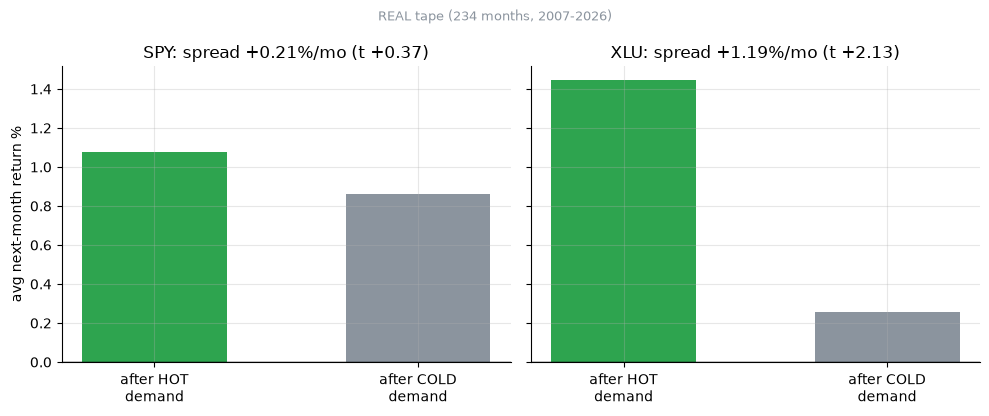

SPY: hot +1.08% cold +0.86% -> spread +0.21%/mo (t +0.37)
XLU: hot +1.44% cold +0.26% -> spread +1.19%/mo (t +2.13)


In [2]:
if HAVE_REAL:
    sig = st.signal_lagged(PANEL['netgen'])
    out = {}
    for tk in ['SPY','XLU']:
        cs = st.conditional_split(sig, PANEL[tk], horizon=1)
        out[tk] = (cs['hot_mean']*100, cs['cold_mean']*100, cs['spread']*100, cs['t'])
    banner = 'REAL tape (234 months, 2007-2026)'
else:
    out = {'SPY': (1.08, 0.86, 0.21, 0.37),
           'XLU': (1.44, 0.26, 1.19, 2.13)}
    banner = 'frozen real numbers (offline)'
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, tk in zip(axes, ['SPY','XLU']):
    hot, cold, spr, t = out[tk]
    ax.bar(['after HOT\ndemand','after COLD\ndemand'], [hot, cold], color=[GREEN, GREY], width=.55)
    ax.axhline(0, c='k', lw=1); ax.set_title(f'{tk}: spread {spr:+.2f}%/mo (t {t:+.2f})')
axes[0].set_ylabel('avg next-month return %')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
for tk in ['SPY','XLU']:
    hot, cold, spr, t = out[tk]; print(f'{tk}: hot +{hot:.2f}% cold +{cold:.2f}% -> spread {spr:+.2f}%/mo (t {t:+.2f})')

For **SPY the answer is basically nothing** — hot and cold months look the same (spread +0.21%, *t* 0.37). For **XLU (utilities)** there's a real gap: +1.19%/mo more after hot demand (*t* 2.13). Utilities *do* seem to respond to the grid pulse. But before we get excited — is that a repeatable pattern, or one big moment?

**The honesty check: what happens if we remove 2020?** In 2020 the lockdown crushed electricity demand *and* the stock market at the same time — a single dramatic event that can look like 'demand predicts returns'.

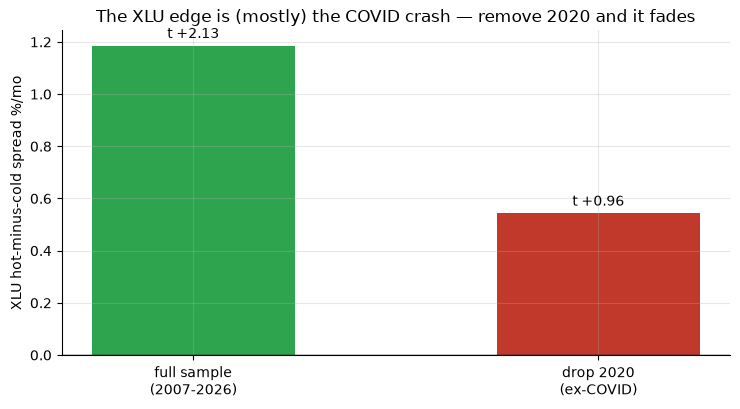

XLU spread full +1.19% (t +2.13) -> ex-2020 +0.54% (t +0.96)


In [3]:
labels = ['full sample\n(2007-2026)', 'drop 2020\n(ex-COVID)']
if HAVE_REAL:
    sig = st.signal_lagged(PANEL['netgen'])
    full = st.conditional_split(sig, PANEL['XLU'], 1)
    m = ~((PANEL.index >= '2020-01-01') & (PANEL.index <= '2020-12-31'))
    px = PANEL[m]; sx = st.signal_lagged(px['netgen'])
    ex = st.conditional_split(sx, px['XLU'], 1)
    spreads = [full['spread']*100, ex['spread']*100]; ts = [full['t'], ex['t']]
else:
    spreads = [1.19, 0.54]; ts = [2.13, 0.96]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
cols = [GREEN if t>2 else RED for t in ts]
bars = ax.bar(labels, spreads, color=cols, width=.5)
for b, t in zip(bars, ts): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.03, f't {t:+.2f}', ha='center')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('XLU hot-minus-cold spread %/mo')
ax.set_title('The XLU edge is (mostly) the COVID crash — remove 2020 and it fades')
plt.tight_layout(); plt.show()
print(f'XLU spread full {spreads[0]:+.2f}% (t {ts[0]:+.2f}) -> ex-2020 {spreads[1]:+.2f}% (t {ts[1]:+.2f})')

There it is. Drop one year — 2020 — and the utilities 'signal' falls from +1.19%/mo (*t* 2.13, looked real) to +0.54%/mo (*t* 0.96, gone). The edge was **one macro event**, not a repeatable pulse.

## 5 · The verdict

- **Signal — Weak.** The broad market shows no forward signal at all; utilities show one borderline reading that is essentially the 2020 crash and dies when you remove it.
- **Tradability — Mirage.** Turning even the utilities pattern into a 'be invested only when demand is hot' rule *loses* to buy-and-hold (next beat).

## 6 · Could you actually trade it?

The natural trade: hold the ETF when demand growth is hot, sit in cash when it's cold. Does it beat just buying and holding?

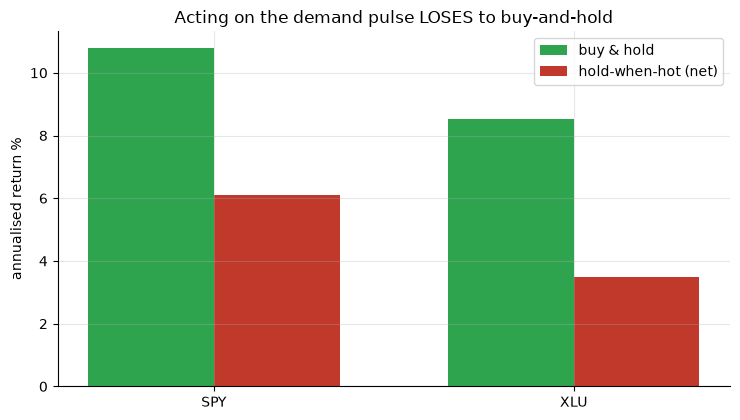

SPY: buy-hold +10.8%/yr vs overlay +6.1%/yr
XLU: buy-hold +8.5%/yr vs overlay +3.5%/yr


In [4]:
if HAVE_REAL:
    sig = st.signal_lagged(PANEL['netgen'])
    res = {tk: st.overlay_backtest(sig, PANEL[tk]) for tk in ['SPY','XLU']}
    bh = [res['SPY']['bh_ann']*100, res['XLU']['bh_ann']*100]
    ov = [res['SPY']['overlay_net_ann']*100, res['XLU']['overlay_net_ann']*100]
else:
    bh = [10.8, 8.5]; ov = [6.1, 3.5]
x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(x-w/2, bh, w, label='buy & hold', color=GREEN)
ax.bar(x+w/2, ov, w, label='hold-when-hot (net)', color=RED)
ax.set_xticks(x); ax.set_xticklabels(['SPY','XLU']); ax.set_ylabel('annualised return %')
ax.set_title('Acting on the demand pulse LOSES to buy-and-hold'); ax.legend()
plt.tight_layout(); plt.show()
for i, tk in enumerate(['SPY','XLU']): print(f'{tk}: buy-hold +{bh[i]:.1f}%/yr vs overlay +{ov[i]:.1f}%/yr')

The overlay underperforms on both tapes — you sit in cash through too much of the rally. Even where the raw pattern looked real (XLU), as a *position* it destroys return. `MIRAGE`.

## 7 · Going further 🚪

- **Same trap, other pulses.** [385 Jobless-Claims-Momentum](../../385-jobless-claims-momentum/) and [269 Baltic-Dry](../../269-baltic-dry/) test the identical 'hard-data leads the market' idea on claims and shipping — both land coincident, not leading.
- **The real test needs higher frequency and cleaner attribution.** Weekly/daily regional grid load, split by industrial vs residential, might isolate the *industrial* pulse that actually leads — beyond a monthly national total dominated by weather.

*Think the pulse is real and we just averaged it away? Fork this, pull weekly EIA-930 balancing-authority load, and show a demand-growth signal clearing t = 2 the right way ex-COVID.*